In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile
import os

# Path of zip file in Google Drive
zip_path = "/content/drive/MyDrive/pest.zip"

# Folder where files will be extracted
extract_path = "/content/pest_dataset"

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
base_dir = '/content/pest_dataset/pest'

In [6]:
os.listdir('/content/pest_dataset/pest')

['train', 'test']

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,   # 20% validation split from train
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

Found 2160 images belonging to 9 classes.


In [9]:
val_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

Found 540 images belonging to 9 classes.


In [10]:
test_generator = test_datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 450 images belonging to 9 classes.


In [11]:
print(train_generator.class_indices)

{'aphids': 0, 'armyworm': 1, 'beetle': 2, 'bollworm': 3, 'grasshopper': 4, 'mites': 5, 'mosquito': 6, 'sawfly': 7, 'stem_borer': 8}


In [12]:
print("Training Images:", train_generator.samples)

Training Images: 2160


In [13]:
print("Test Images:", test_generator.samples)

Test Images: 450


In [14]:
num_classes = len(train_generator.class_indices)
print("Number of Classes:", num_classes)

Number of Classes: 9


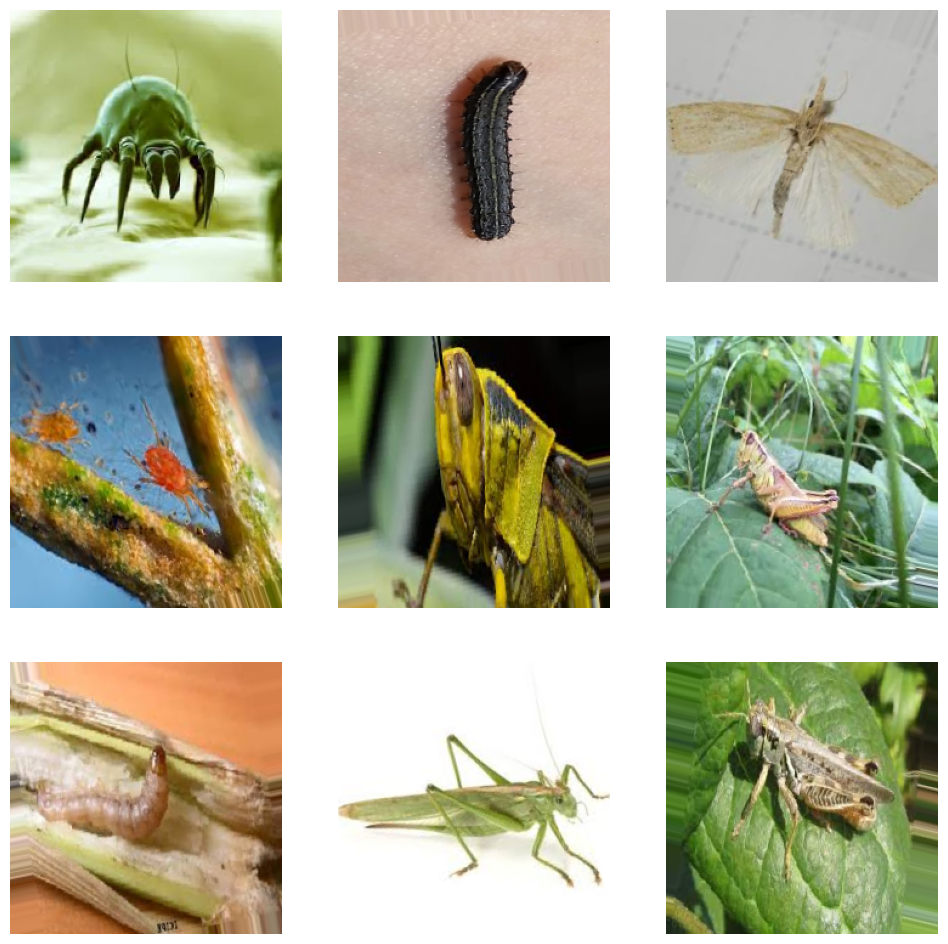

In [15]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

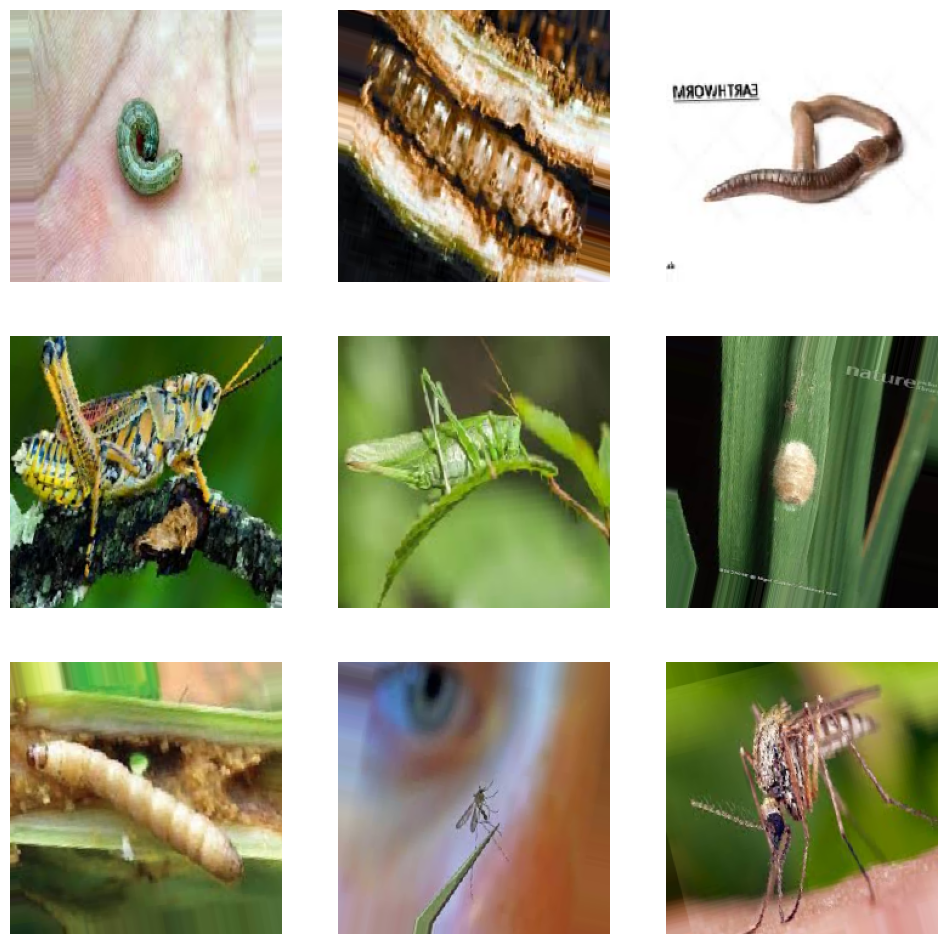

In [16]:
augmented_images, _ = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(augmented_images[i])
    plt.axis("off")

plt.show()

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

baseline_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,561,481 (169.99 MB)

 Trainable params: 44,561,481 (169.99 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 56s 694ms/step - accuracy: 0.1713 - loss: 2.1535 - val_accuracy: 0.2278 - val_loss: 1.9845
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 65s 552ms/step - accuracy: 0.3167 - loss: 1.8313 - val_accuracy: 0.3741 - val_loss: 1.7691
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 598ms/step - accuracy: 0.4843 - loss: 1.4077 - val_accuracy: 0.3519 - val_loss: 1.9274
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 596ms/step - accuracy: 0.6111 - loss: 1.1039 - val_accuracy: 0.3444 - val_loss: 1.9802
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 42s 615ms/step - accuracy: 0.7042 - loss: 0.8397 - val_accuracy: 0.4296 - val_loss: 2.2398
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 575ms/step - accuracy: 0.7870 - loss: 0.6242 - val_accuracy: 0.4241 - val_loss: 2.4818
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 584ms/step - accuracy: 0.8801 - loss: 0.3606 - val_accuracy: 0.5000 - val_loss: 2.4526
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 605ms/step - accuracy: 0.9065 - loss: 0.2750 - val_accu

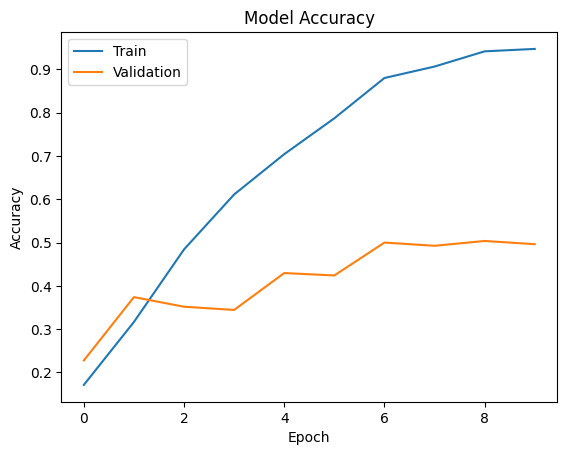

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])

plt.show()

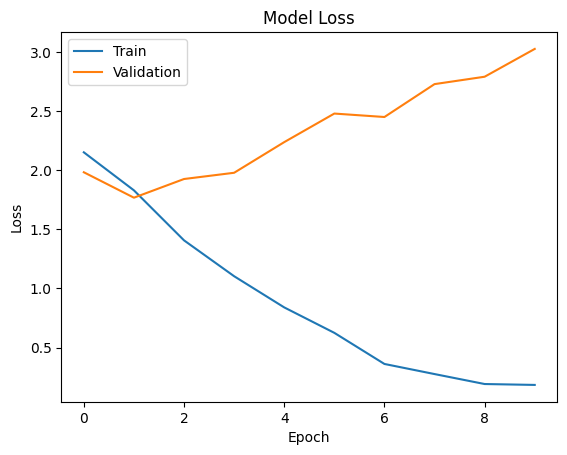

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])

plt.show()

In [23]:
test_loss, test_accuracy = baseline_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.8267 - loss: 1.0106
Test Accuracy: 0.8266666531562805
Test Loss: 1.0105795860290527


In [24]:
from sklearn.metrics import classification_report
import numpy as np

predictions = baseline_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step
              precision    recall  f1-score   support

      aphids       0.75      0.92      0.83        50
    armyworm       0.85      0.78      0.81        50
      beetle       0.88      0.84      0.86        50
    bollworm       0.86      0.84      0.85        50
 grasshopper       0.76      0.94      0.84        50
       mites       0.78      0.64      0.70        50
    mosquito       0.83      0.96      0.89        50
      sawfly       0.87      0.68      0.76        50
  stem_borer       0.91      0.84      0.88        50

    accuracy                           0.83       450
   macro avg       0.83      0.83      0.82       450
weighted avg       0.83      0.83      0.82       450



In [25]:
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam

In [26]:
deep_model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,583,497 (55.63 MB)

 Trainable params: 14,581,513 (55.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [29]:
import time

start_time = time.time()

history_deep = deep_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

end_time = time.time()

training_time = end_time - start_time

print("Total Training Time:", training_time, "seconds")

Epoch 1/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 69s 786ms/step - accuracy: 0.1699 - loss: 6.6029 - val_accuracy: 0.1500 - val_loss: 2.3714
Epoch 2/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 570ms/step - accuracy: 0.1736 - loss: 3.5486 - val_accuracy: 0.1648 - val_loss: 2.2896
Epoch 3/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 608ms/step - accuracy: 0.1843 - loss: 2.5915 - val_accuracy: 0.1778 - val_loss: 2.3237
Epoch 4/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 608ms/step - accuracy: 0.2014 - loss: 2.3227 - val_accuracy: 0.1278 - val_loss: 2.1795
Epoch 5/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 43s 631ms/step - accuracy: 0.2176 - loss: 2.1739 - val_accuracy: 0.1630 - val_loss: 2.1690
Epoch 6/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 43s 627ms/step - accuracy: 0.2426 - loss: 2.0699 - val_accuracy: 0.1704 - val_loss: 2.1134
Epoch 7/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 592ms/step - accuracy: 0.2713 - loss: 2.0046 - val_accuracy: 0.1500 - val_loss: 2.1299
Epoch 8/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 591ms/step - accuracy: 0.2894 - loss: 1.9106 - val_accu

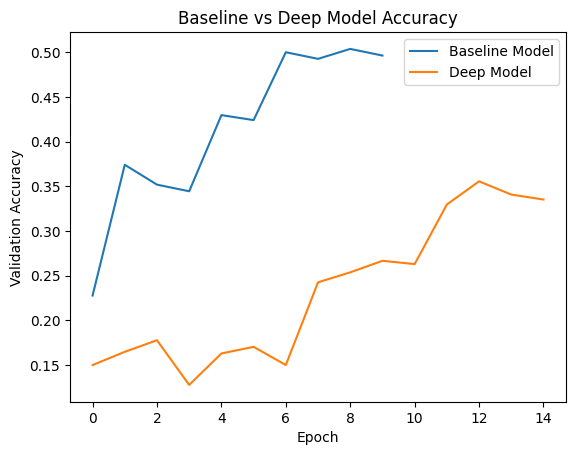

In [30]:
plt.plot(history.history['val_accuracy'], label='Baseline Model')
plt.plot(history_deep.history['val_accuracy'], label='Deep Model')

plt.title("Baseline vs Deep Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

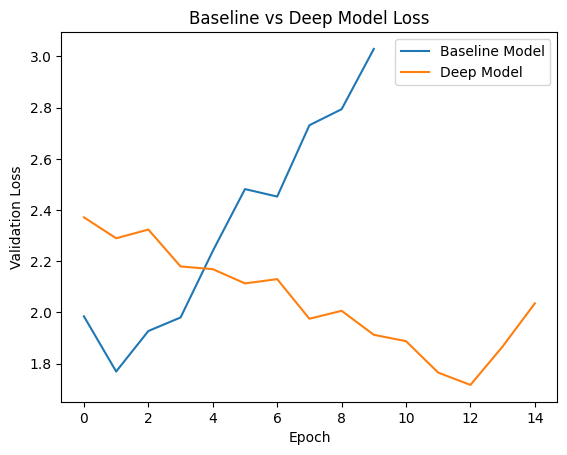

In [31]:
plt.plot(history.history['val_loss'], label='Baseline Model')
plt.plot(history_deep.history['val_loss'], label='Deep Model')

plt.title("Baseline vs Deep Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.show()

In [32]:
deep_loss, deep_accuracy = deep_model.evaluate(test_generator)

print("Deep Model Accuracy:", deep_accuracy)
print("Deep Model Loss:", deep_loss)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.4244 - loss: 1.6453
Deep Model Accuracy: 0.42444443702697754
Deep Model Loss: 1.6453053951263428


In [33]:
deep_predictions = deep_model.predict(test_generator)

deep_predicted_classes = np.argmax(deep_predictions, axis=1)

print(classification_report(
    true_classes,
    deep_predicted_classes,
    target_names=class_labels
))

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
              precision    recall  f1-score   support

      aphids       0.75      0.54      0.63        50
    armyworm       0.60      0.06      0.11        50
      beetle       0.41      0.82      0.54        50
    bollworm       0.41      0.32      0.36        50
 grasshopper       0.39      0.46      0.42        50
       mites       0.33      0.34      0.33        50
    mosquito       0.51      0.96      0.66        50
      sawfly       0.21      0.22      0.22        50
  stem_borer       0.45      0.10      0.16        50

    accuracy                           0.42       450
   macro avg       0.45      0.42      0.38       450
weighted avg       0.45      0.42      0.38       450



In [34]:
sgd_model = deep_model

sgd_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 51s 658ms/step - accuracy: 0.4829 - loss: 1.4300 - val_accuracy: 0.3741 - val_loss: 1.6893
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 585ms/step - accuracy: 0.4843 - loss: 1.4122 - val_accuracy: 0.3574 - val_loss: 1.7117
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 584ms/step - accuracy: 0.4861 - loss: 1.4007 - val_accuracy: 0.3944 - val_loss: 1.6985
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 572ms/step - accuracy: 0.5009 - loss: 1.3776 - val_accuracy: 0.4093 - val_loss: 1.6665
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 572ms/step - accuracy: 0.4963 - loss: 1.3963 - val_accuracy: 0.4111 - val_loss: 1.6580
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 601ms/step - accuracy: 0.5134 - loss: 1.3497 - val_accuracy: 0.4222 - val_loss: 1.6437
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 608ms/step - accuracy: 0.5088 - loss: 1.3525 - val_accuracy: 0.4074 - val_loss: 1.7112
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 38s 558ms/step - accuracy: 0.5144 - loss: 1.3292 - val_accu

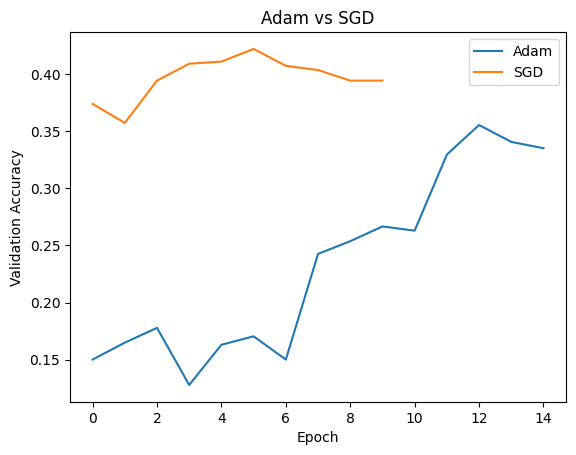

In [35]:
plt.plot(history_deep.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')

plt.title("Adam vs SGD")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

In [36]:
ablation_model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dense(256, activation='relu'),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 54s 684ms/step - accuracy: 0.3019 - loss: 10.8200 - val_accuracy: 0.1111 - val_loss: 21.7283
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 602ms/step - accuracy: 0.4509 - loss: 2.7648 - val_accuracy: 0.1389 - val_loss: 15.3769
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 581ms/step - accuracy: 0.5759 - loss: 1.5902 - val_accuracy: 0.1444 - val_loss: 11.1465
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 600ms/step - accuracy: 0.7046 - loss: 0.9953 - val_accuracy: 0.2019 - val_loss: 11.5914
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 601ms/step - accuracy: 0.7755 - loss: 0.7798 - val_accuracy: 0.1593 - val_loss: 9.3730
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 42s 618ms/step - accuracy: 0.8310 - loss: 0.5591 - val_accuracy: 0.1796 - val_loss: 9.3340
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 580ms/step - accuracy: 0.8736 - loss: 0.3983 - val_accuracy: 0.2130 - val_loss: 7.3575
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 573ms/step - accuracy: 0.9032 - loss: 0.3127 - val

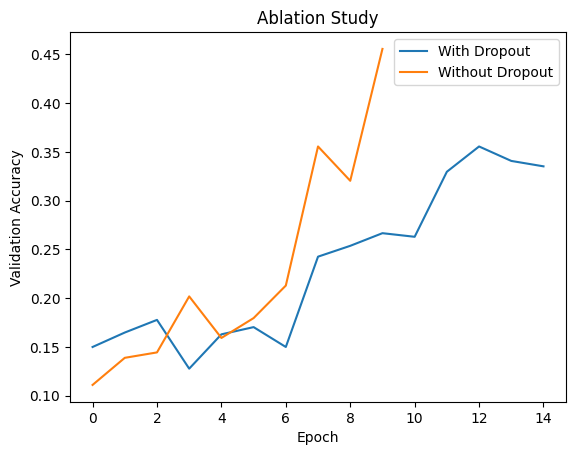

In [38]:
plt.plot(history_deep.history['val_accuracy'], label='With Dropout')
plt.plot(history_ablation.history['val_accuracy'], label='Without Dropout')

plt.title("Ablation Study")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

In [39]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [40]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
for layer in base_model.layers:
    layer.trainable = False

In [42]:
x = base_model.output

x = Flatten()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)

predictions = Dense(num_classes, activation='softmax')(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [43]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
transfer_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,693,897 (105.64 MB)

 Trainable params: 12,979,209 (49.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [45]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.3306 - loss: 1.8714 - val_accuracy: 0.4407 - val_loss: 1.6132
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 44s 653ms/step - accuracy: 0.5894 - loss: 1.2443 - val_accuracy: 0.6056 - val_loss: 1.2166
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 81s 651ms/step - accuracy: 0.7134 - loss: 0.9006 - val_accuracy: 0.5630 - val_loss: 1.2491
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 656ms/step - accuracy: 0.7861 - loss: 0.6773 - val_accuracy: 0.5852 - val_loss: 1.1947
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 666ms/step - accuracy: 0.8458 - loss: 0.5216 - val_accuracy: 0.6241 - val_loss: 1.1340
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 658ms/step - accuracy: 0.8866 - loss: 0.3981 - val_accuracy: 0.6667 - val_loss: 1.0939
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 658ms/step - accuracy: 0.9208 - loss: 0.3011 - val_accuracy: 0.6556 - val_loss: 1.1084
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 660ms/step - accuracy: 0.9435 - loss: 0.2368 - val_accurac

In [46]:
transfer_loss, transfer_accuracy = transfer_model.evaluate(test_generator)

print("Transfer Learning Accuracy:", transfer_accuracy)
print("Transfer Learning Loss:", transfer_loss)

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 435ms/step - accuracy: 0.8689 - loss: 0.4613
Transfer Learning Accuracy: 0.8688889145851135
Transfer Learning Loss: 0.4612634479999542


In [47]:
transfer_predictions = transfer_model.predict(test_generator)

transfer_predicted_classes = np.argmax(
    transfer_predictions,
    axis=1
)

print(classification_report(
    true_classes,
    transfer_predicted_classes,
    target_names=class_labels
))

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 253ms/step
              precision    recall  f1-score   support

      aphids       0.85      0.88      0.86        50
    armyworm       0.98      0.86      0.91        50
      beetle       0.94      0.94      0.94        50
    bollworm       0.70      0.92      0.79        50
 grasshopper       0.96      0.98      0.97        50
       mites       0.92      0.72      0.81        50
    mosquito       0.94      0.96      0.95        50
      sawfly       0.85      0.70      0.77        50
  stem_borer       0.77      0.86      0.81        50

    accuracy                           0.87       450
   macro avg       0.88      0.87      0.87       450
weighted avg       0.88      0.87      0.87       450



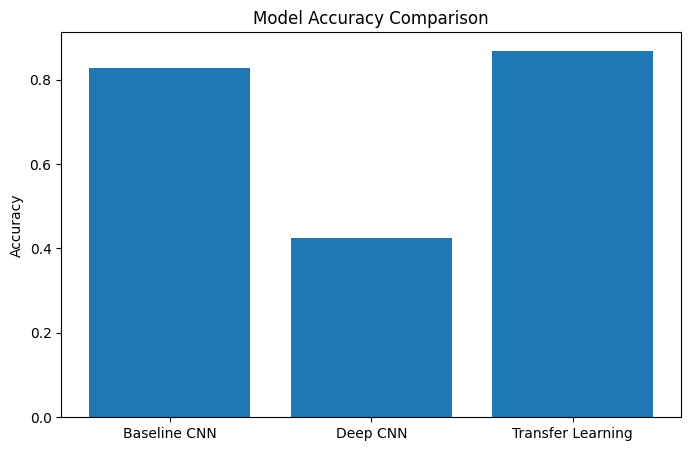

In [48]:
models = ['Baseline CNN', 'Deep CNN', 'Transfer Learning']

accuracies = [
    test_accuracy,
    deep_accuracy,
    transfer_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

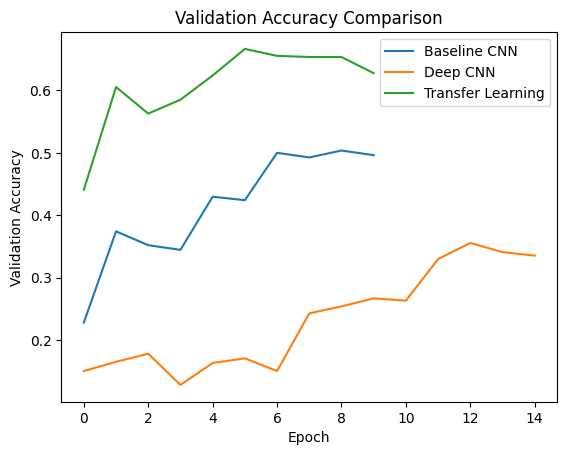

In [49]:
plt.plot(history.history['val_accuracy'], label='Baseline CNN')

plt.plot(history_deep.history['val_accuracy'], label='Deep CNN')

plt.plot(history_transfer.history['val_accuracy'], label='Transfer Learning')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

In [50]:
for layer in base_model.layers[-4:]:
    layer.trainable = True

In [51]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
history_finetune = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 61s 784ms/step - accuracy: 0.9778 - loss: 0.0902 - val_accuracy: 0.6574 - val_loss: 1.4403
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 657ms/step - accuracy: 0.9843 - loss: 0.0628 - val_accuracy: 0.6574 - val_loss: 1.4272
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 655ms/step - accuracy: 0.9875 - loss: 0.0523 - val_accuracy: 0.6648 - val_loss: 1.4289
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 656ms/step - accuracy: 0.9931 - loss: 0.0334 - val_accuracy: 0.6815 - val_loss: 1.5442
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 660ms/step - accuracy: 0.9940 - loss: 0.0274 - val_accuracy: 0.6741 - val_loss: 1.4882


In [53]:
fine_tune_loss, fine_tune_accuracy = transfer_model.evaluate(test_generator)

print("Fine-Tuned Model Accuracy:", fine_tune_accuracy)
print("Fine-Tuned Model Loss:", fine_tune_loss)

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.9000 - loss: 0.5735
Fine-Tuned Model Accuracy: 0.8999999761581421
Fine-Tuned Model Loss: 0.5734682083129883


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step


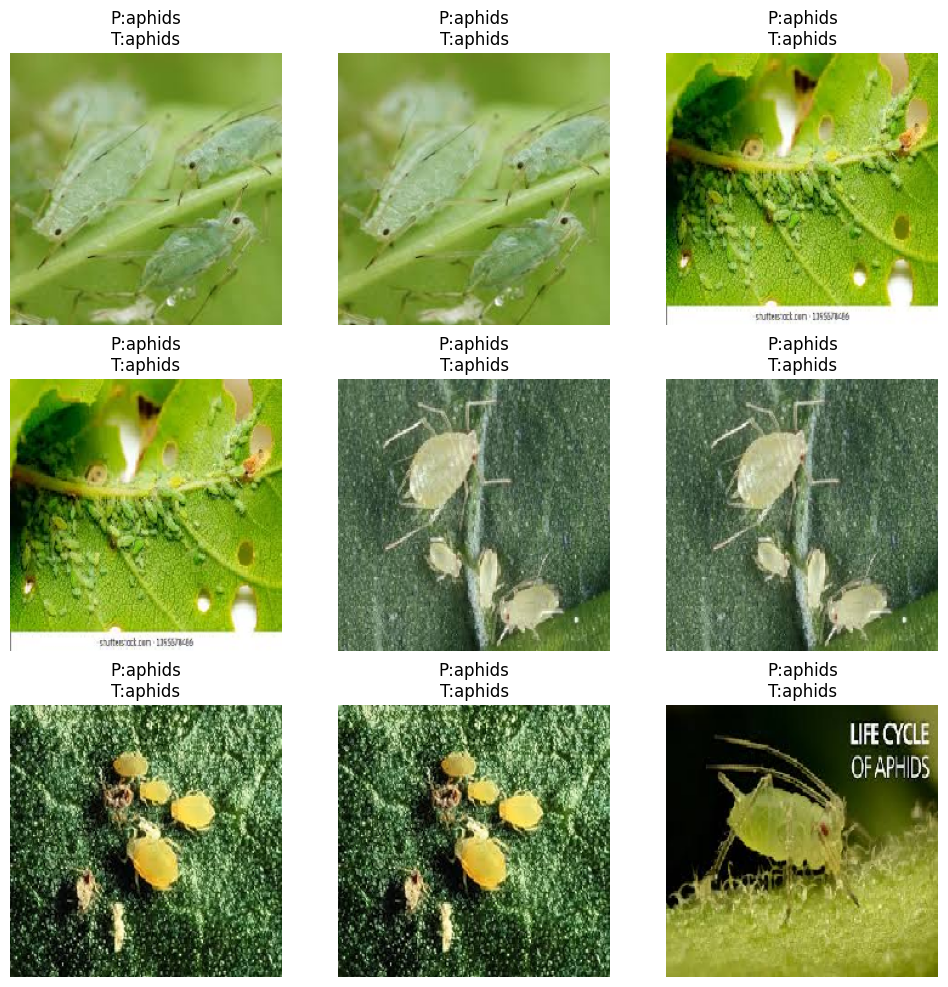

In [54]:
images, labels = next(test_generator)

predictions = transfer_model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)

true_classes_batch = np.argmax(labels, axis=1)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    predicted_label = class_labels[predicted_classes[i]]
    true_label = class_labels[true_classes_batch[i]]

    plt.title(f"P:{predicted_label}\nT:{true_label}")

    plt.axis("off")

plt.show()

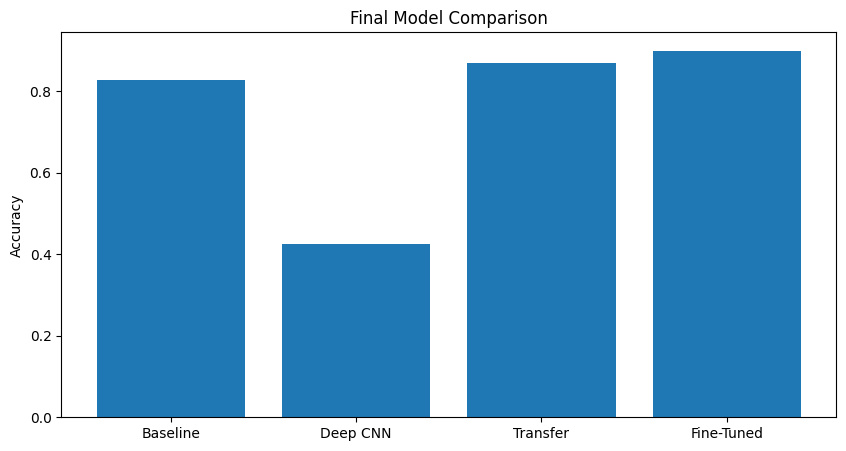

In [55]:
models = [
    'Baseline',
    'Deep CNN',
    'Transfer',
    'Fine-Tuned'
]

accuracies = [
    test_accuracy,
    deep_accuracy,
    transfer_accuracy,
    fine_tune_accuracy
]

plt.figure(figsize=(10,5))

plt.bar(models, accuracies)

plt.title("Final Model Comparison")
plt.ylabel("Accuracy")

plt.show()